# exploring YBT

In [2]:
# load basic info 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data 
df = pd.read_csv('/Users/eb2007/playground/bullpy/c4_play2/data/raw/YBT.csv')

# check basic info 
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (24205, 83)

Data types:
Progress                 object
Duration (in seconds)    object
Finished                 object
RecordedDate             object
ResponseId               object
                          ...  
aq_9                     object
aq_10                    object
SC7                      object
SC8                      object
SC52                     object
Length: 83, dtype: object

Missing values:
Progress                     0
Duration (in seconds)        0
Finished                     0
RecordedDate                 0
ResponseId                   0
                         ...  
aq_9                     10024
aq_10                    10036
SC7                          0
SC8                          0
SC52                         0
Length: 83, dtype: int64


/var/folders/1b/r6y9_1zx175chs6rm5vj_xfc0000gp/T/ipykernel_17581/601131350.py:8: DtypeWarning: Columns (0,1,2,31,32,33,34,35,36,37,38,39,48,49,80,81,82) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/eb2007/playground/bullpy/c4_play2/data/raw/YBT.csv')


In [3]:
# examine diagnosis column 
print("diagnosis columns:")
print(df['diagnosis_yes_no'].value_counts())
print(df['diagnosis'].value_counts().head(20))


diagnosis columns:
diagnosis_yes_no
No                                                                                                                      12743
Yes                                                                                                                      5581
I do not know                                                                                                             857
I prefer not to say                                                                                                       530
8. Have you ever been formally diagnosed with a mental health and/or neurodevelopmental condition by a professional?        1
{"ImportId":"QID281"}                                                                                                       1
Name: count, dtype: int64
diagnosis
I have not been diagnosed with any of the conditions listed below                                                                                2288
Anxiety Disorder (e.g.

In [4]:
# create autism target variable 
print("creating autism target variable")

# filter out non responses and create inital flag
valid_diagnosis = df['diagnosis_yes_no'].isin(['yes', 'no'])
autism_from_yes_no = df['diagnosis_yes_no'].str.lower() == 'yes'

print(f"participants with 'yes' in diagnosis: {autism_from_yes_no.sum()}")
print(f"participants with 'no' in diagnosis: {(df['diagnosis_yes_no'].str.lower() == 'no').sum()}")

# check for autism related terms in diagnosis column 
autism_keywords = ['autism', 'ASD', 'asperger', 'autistic']
autism_from_diagnosis = df['diagnosis'].str.contains('|'.join(autism_keywords), case=False, na=False)

print(f"participants with autism in diagnosis: {autism_from_diagnosis.sum()}")

# check for specific autism mentions
autism_specific = df['diagnosis'].str.contains('Autism', case=False, na=False)
print(f"participants with 'Autism' specifically mentioned: {autism_specific.sum()}")

# Strict target: Only explicit "Autism" mention in diagnosis field
df['autism_target'] = df['diagnosis'].str.contains('autism', case=False, na=False).astype(int)

# Analysis of target variable
print("\n===target variable analysis===")
print(f"total participants: {len(df)}")
print(f"autism cases: {df['autism_target'].sum()}")
print(f"non-autism cases: {(df['autism_target'] == 0).sum()}")
print(f"autism percentage: {df['autism_target'].mean() * 100:.2f}%")

# check class imbalance 
print("\n===class imbalance===")
print(f"autism: {df['autism_target'].sum()} ({df['autism_target'].mean() * 100:.2f}%)")
print(f"non-autism: {(df['autism_target'] == 0).sum()} ({(1-df['autism_target'].mean()) * 100:.1f}%)")


# Verify with diagnosis field
print(f"\n=== VERIFICATION ===")
print("Autism cases breakdown:")
autism_cases = df[df['autism_target'] == 1]
print(autism_cases['diagnosis'].value_counts().head(10))

# Check for potential false positives/negatives
print(f"\n=== POTENTIAL ISSUES ===")
print("Cases with 'Yes' but no autism in diagnosis:")
yes_no_autism = df[(df['diagnosis_yes_no'] == 'Yes') & (~autism_from_diagnosis.fillna(False))]
print(f"Count: {len(yes_no_autism)}")
if len(yes_no_autism) > 0:
    print(yes_no_autism['diagnosis'].value_counts().head(5))

print("\nCases with autism in diagnosis but 'No' to diagnosis_yes_no:")
autism_but_no = df[(autism_from_diagnosis) & (df['diagnosis_yes_no'] == 'No')]
print(f"Count: {len(autism_but_no)}")
if len(autism_but_no) > 0:
    print(autism_but_no['diagnosis'].value_counts().head(5))

creating autism target variable
participants with 'yes' in diagnosis: 5581
participants with 'no' in diagnosis: 12743
participants with autism in diagnosis: 758
participants with 'Autism' specifically mentioned: 758

===target variable analysis===
total participants: 24205
autism cases: 758
non-autism cases: 23447
autism percentage: 3.13%

===class imbalance===
autism: 758 (3.13%)
non-autism: 23447 (96.9%)

=== VERIFICATION ===
Autism cases breakdown:
diagnosis
Autism                                                                                            163
ADHD,Autism                                                                                        86
ADHD,Anxiety Disorder (e.g., Generalized Anxiety Disorder),Autism,Depression                       72
Anxiety Disorder (e.g., Generalized Anxiety Disorder),Autism,Depression                            45
ADHD,Autism,Depression                                                                             32
ADHD,Anxiety Disorder (e

# initial EDA 
- on unprocessed data

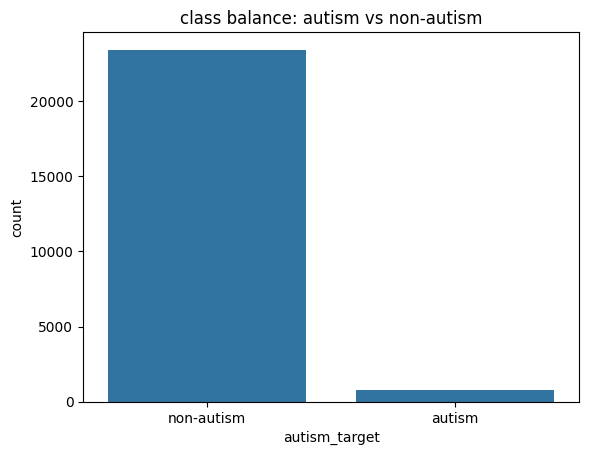

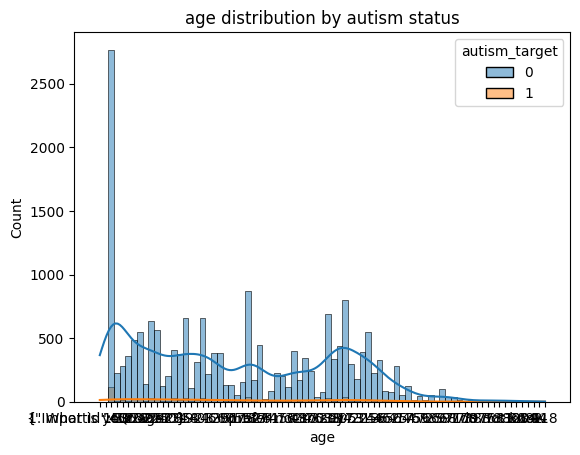

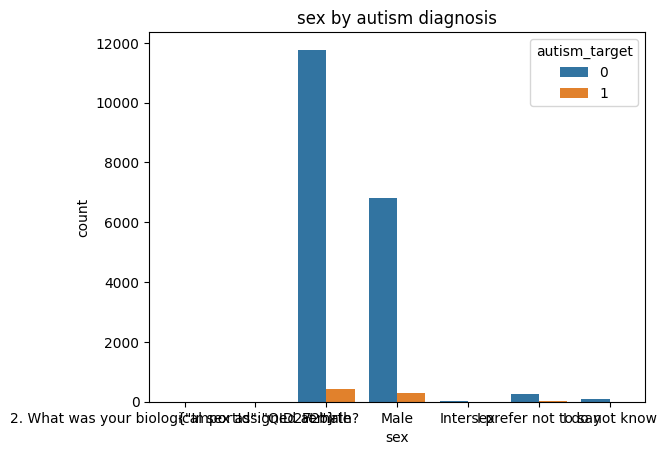

In [5]:
# explore class imbalance and demographics 

# class imbalance 
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='autism_target', data=df)
plt.title('class balance: autism vs non-autism')
plt.xticks([0, 1], ['non-autism', 'autism'])
plt.show()

# demographic distributions 
# age 
sns.histplot(data=df, x='age', hue='autism_target',bins=30, kde=True)
plt.title('age distribution by autism status')
plt.show()

# sex 
if 'sex' in df.columns:
    sns.countplot(x='sex', hue='autism_target', data=df)
    plt.title('sex by autism diagnosis')
    plt.show()

eq10_1: ['1. I am good at predicting how someone will feel.'
 '{"ImportId":"QID18"}' nan 'strongly agree' 'slightly agree'
 'slightly disagree' 'strongly disagree']
eq10_2: ['2. Other people tell me I am good at understanding how they are feeling and what they are thinking.'
 '{"ImportId":"QID19"}' nan 'strongly agree' 'slightly agree'
 'slightly disagree' 'strongly disagree']
eq10_3: ['3. It is hard for me to see why some things upset people so much.'
 '{"ImportId":"QID4"}' nan 'strongly agree' 'strongly disagree'
 'slightly agree' 'slightly disagree']
eq10_4: ['4. I can easily work out what another person might want to talk about.'
 '{"ImportId":"QID20"}' nan 'strongly agree' 'strongly disagree'
 'slightly agree' 'slightly disagree']
eq10_5: ["5. I can't always see why someone should have been offended by a remark."
 '{"ImportId":"QID21"}' nan 'strongly agree' 'slightly disagree'
 'slightly agree' 'strongly disagree']
eq10_6: ['6. I can tune into how someone feels rapidly and intuiti

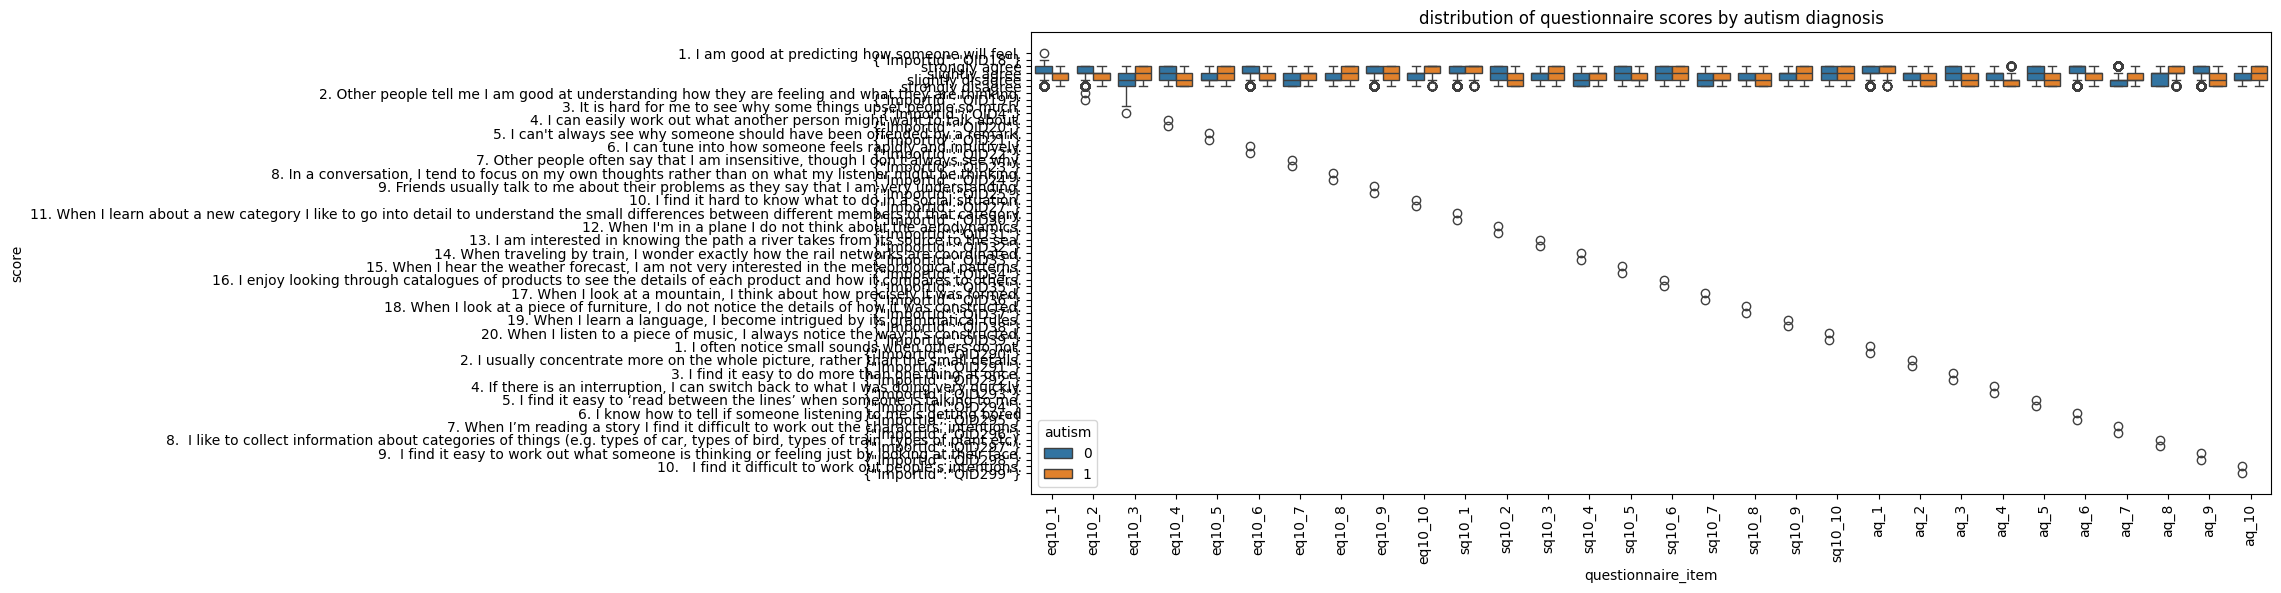

In [6]:
# explore questionaire data 

# list questionnaire columns
questionnaire_cols = [col for col in df.columns if any(q in col for q in ['eq10_', 'sq10_', 'aq_'])]

# check for non-numeric values 
for col in questionnaire_cols:
    print(f"{col}: {df[col].unique()}")

# visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = df.melt(id_vars=['autism_target'], value_vars=questionnaire_cols,
                    var_name='questionnaire_item', value_name='score')

plt.figure(figsize=(16, 6))
sns.boxplot(x='questionnaire_item', y='score', hue='autism_target', data=df_melted)
plt.title('distribution of questionnaire scores by autism diagnosis')
plt.xticks(rotation=90)
plt.legend(title='autism')
plt.show()



eq10_1      8856
eq10_2      8980
eq10_3      9064
eq10_4      9145
eq10_5      9259
eq10_6      9347
eq10_7      9407
eq10_8      9446
eq10_9      9475
eq10_10     9502
sq10_1      9581
sq10_2      9600
sq10_3      9616
sq10_4      9631
sq10_5      9643
sq10_6      9666
sq10_7      9672
sq10_8      9686
sq10_9      9695
sq10_10     9699
aq_1        9839
aq_2        9889
aq_3        9909
aq_4        9938
aq_5        9960
aq_6        9972
aq_7        9987
aq_8       10005
aq_9       10024
aq_10      10036
age         4492
sex         4492
dtype: int64


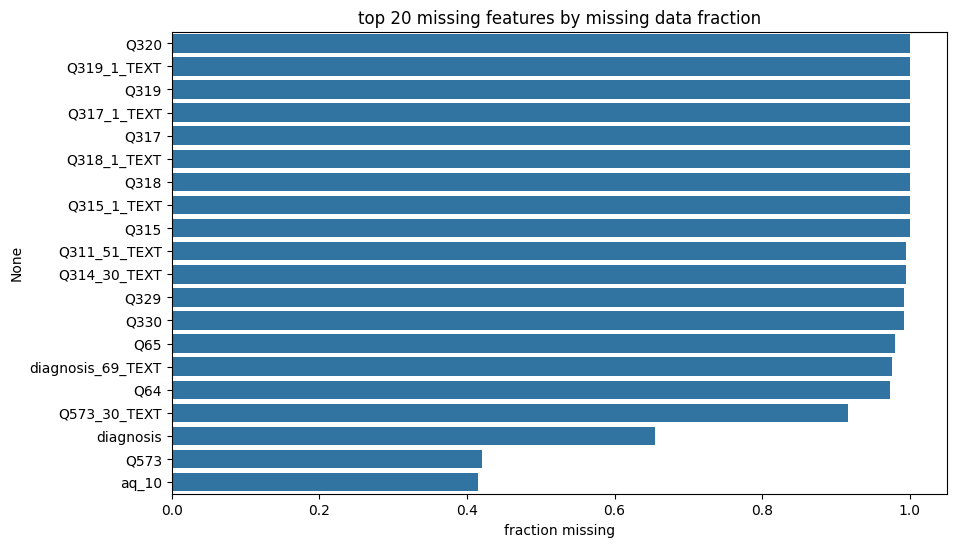

In [7]:
# check and handle missing data in key cols 
print(df[questionnaire_cols + ['age', 'sex']].isnull().sum())

# visualize missing data 
missing = df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing.head(20), y=missing.head(20).index)
plt.title('top 20 missing features by missing data fraction')
plt.xlabel('fraction missing')
plt.show()

# preprocessing prep

In [8]:
# prepare for preprocessing 

# example mapping for likert responses 
response_mapping = {
    'strongly disagree': 1, 'slightly disagree': 2,
    'slightly agree': 3, 'strongly agree': 4
}
for col in questionnaire_cols:
    df[col] = df[col].map(response_mapping).astype(float)

print(df[questionnaire_cols].head())

   eq10_1  eq10_2  eq10_3  eq10_4  eq10_5  eq10_6  eq10_7  eq10_8  eq10_9  \
0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
1     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3     4.0     4.0     4.0     4.0     4.0     4.0     4.0     4.0     4.0   
4     3.0     3.0     1.0     1.0     4.0     3.0     3.0     4.0     4.0   

   eq10_10  ...  aq_1  aq_2  aq_3  aq_4  aq_5  aq_6  aq_7  aq_8  aq_9  aq_10  
0      NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN  
1      NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN  
2      NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN  
3      4.0  ...   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0    4.0  
4      3.0  ...   3.0   1.0   3.0   2.0   4.0   4.0   3.0   3.0   2.0    3.0  

[5 rows x 30 columns]


# preprocessing

In [9]:
# check which demographic columns are actually in the dataframe
available_demographic_cols = ['sex', 'country']
print("Available demographic columns:", [col for col in ['sex', 'handedness', 'education', 'occupation', 'country'] if col in df.columns])

# impute demographic columns with 'unknown' (only for columns that exist)
for col in available_demographic_cols:
    df[col] = df[col].fillna('unknown')

# impute questionnaire scores with median 
for col in questionnaire_cols:
    df[col] = df[col].fillna(df[col].median())

print(df[available_demographic_cols].head())

Available demographic columns: ['sex', 'country']
                                                 sex  \
0  2. What was your biological sex assigned at bi...   
1                              {"ImportId":"QID272"}   
2                                            unknown   
3                                             Female   
4                                             Female   

                                 country  
0  6. What is your country of residence?  
1                  {"ImportId":"QID278"}  
2                                unknown  
3                          Aland Islands  
4                          United States  


eq10_1: [3. 4. 2. 1.]
eq10_2: [3. 4. 2. 1.]
eq10_3: [2. 4. 1. 3.]
eq10_4: [3. 4. 1. 2.]
eq10_5: [2. 4. 3. 1.]
eq10_6: [3. 4. 2. 1.]
eq10_7: [2. 4. 3. 1.]
eq10_8: [2. 4. 1. 3.]
eq10_9: [3. 4. 2. 1.]
eq10_10: [3. 4. 2. 1.]
sq10_1: [3. 4. 2. 1.]
sq10_2: [3. 4. 1. 2.]
sq10_3: [3. 4. 2. 1.]
sq10_4: [2. 4. 1. 3.]
sq10_5: [3. 4. 2. 1.]
sq10_6: [3. 4. 2. 1.]
sq10_7: [2. 4. 1. 3.]
sq10_8: [2. 4. 1. 3.]
sq10_9: [3. 4. 1. 2.]
sq10_10: [3. 4. 2. 1.]
aq_1: [3. 4. 2. 1.]
aq_2: [3. 4. 1. 2.]
aq_3: [3. 4. 1. 2.]
aq_4: [3. 4. 2. 1.]
aq_5: [3. 4. 2. 1.]
aq_6: [4. 1. 3. 2.]
aq_7: [2. 4. 3. 1.]
aq_8: [3. 4. 2. 1.]
aq_9: [3. 4. 2. 1.]
aq_10: [2. 4. 3. 1.]


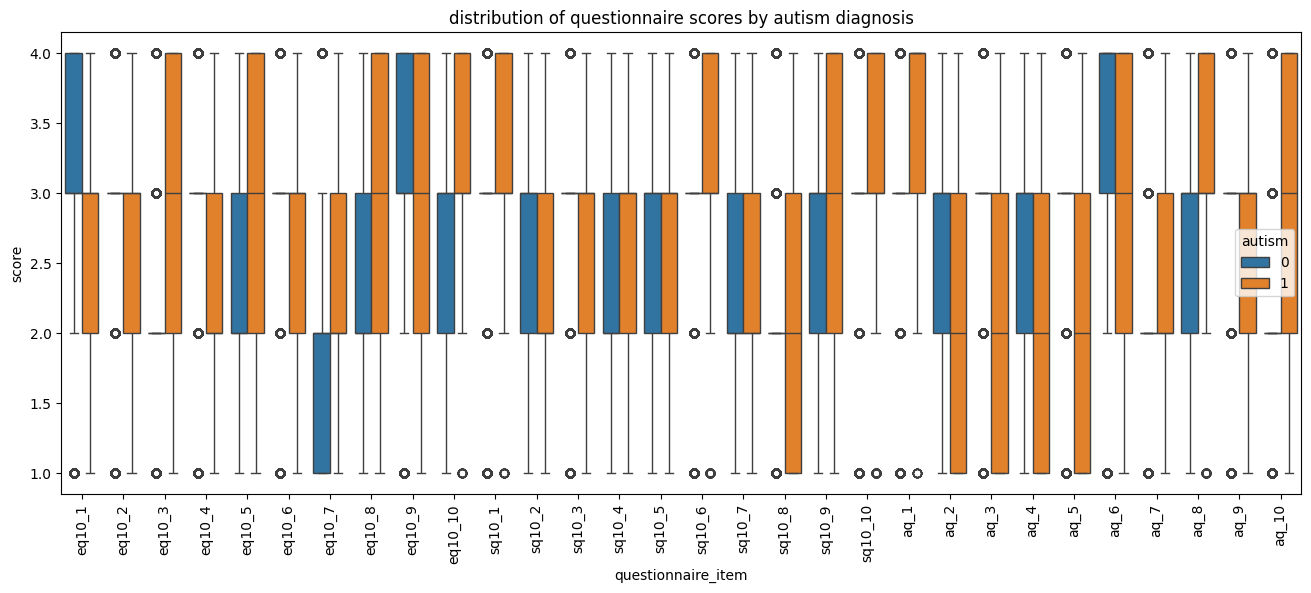

In [10]:
# explore questionaire data 

# list questionnaire columns
questionnaire_cols = [col for col in df.columns if any(q in col for q in ['eq10_', 'sq10_', 'aq_'])]

# check for non-numeric values 
for col in questionnaire_cols:
    print(f"{col}: {df[col].unique()}")

# visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = df.melt(id_vars=['autism_target'], value_vars=questionnaire_cols,
                    var_name='questionnaire_item', value_name='score')

plt.figure(figsize=(16, 6))
sns.boxplot(x='questionnaire_item', y='score', hue='autism_target', data=df_melted)
plt.title('distribution of questionnaire scores by autism diagnosis')
plt.xticks(rotation=90)
plt.legend(title='autism')
plt.show()



# feature engineering

In [14]:
print(df.columns.tolist())
print(df['age'].unique())

['Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'age', 'sex', 'gender', 'ethn', 'hand', 'country', 'English', 'diagnosis_yes_no', 'diagnosis', 'diagnosis_69_TEXT', 'Q311', 'Q56', 'Q57', 'Q58', 'Q59', 'Q60', '18. how many childr ', '19. non biological ', 'Q64', 'Q65', 'edu', 'Q549', 'Q573', 'Q573_30_TEXT', 'Q314', 'Q314_30_TEXT', 'Q315', 'Q315_1_TEXT', 'Q318', 'Q318_1_TEXT', 'Q317', 'Q317_1_TEXT', 'Q319', 'Q319_1_TEXT', 'Q320', 'Q311.1', 'Q311_51_TEXT', 'Q329', 'Q330', 'Q321', 'Q322', 'Q323', 'Q324', 'Q326', 'Q327', 'eq10_1', 'eq10_2', 'eq10_3', 'eq10_4', 'eq10_5', 'eq10_6', 'eq10_7', 'eq10_8', 'eq10_9', 'eq10_10', 'sq10_1', 'sq10_2', 'sq10_3', 'sq10_4', 'sq10_5', 'sq10_6', 'sq10_7', 'sq10_8', 'sq10_9', 'sq10_10', 'aq_1', 'aq_2', 'aq_3', 'aq_4', 'aq_5', 'aq_6', 'aq_7', 'aq_8', 'aq_9', 'aq_10', 'SC7', 'SC8', 'SC52', 'autism_target', 'eq_total', 'sq_total', 'aq_total', 'd_score']
['1. What is your age?' '{"ImportId":"QID271"}' nan '16' '45' '39' '35'
 '26' 

In [15]:
# --- aggregate questionnaire scores --- 
df['eq_total'] = df[[f'eq10_{i}' for i in range(1, 11)]].sum(axis=1)
df['sq_total'] = df[[f'sq10_{i}' for i in range(1, 11)]].sum(axis=1)
df['aq_total'] = df[[f'aq_{i}' for i in range(1, 11)]].sum(axis=1)

# --- D-score ---
df['d_score'] = df['eq_total'] - df['sq_total']

# --- Age group bins (categorical) ---
# convert 'prefer not to say' to NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')
# create age group bins
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 100], labels=['0-18', '19-30', '31-45', '46-60', '61+'])

# --- nonlinear transformations ---
df['log_aq_total'] = np.log1p(df['aq_total'])
df['sqrt_age'] = np.sqrt(df['age'])

# --- interaction terms ---
df['aq_eq_interaction'] = df['aq_total'] * df['eq_total']
df['aq_sq_interaction'] = df['aq_total'] * df['sq_total']
df['age_x_eq'] = df['age'] * df['eq_total']

# --- questionnaire score ratios ---
df['aq_eq_ratio'] = df['aq_total'] / (df['eq_total'] + 1e-8)
df['eq_sq_ratio'] = df['eq_total'] / (df['sq_total'] + 1e-8)
df['sq_aq_ratio'] = df['sq_total'] / (df['aq_total'] + 1e-8)

# --- boolean high sq (above 1 std) ---
df['high_aq'] = (df['aq_total'] > df['aq_total'].mean() + df['aq_total'].std()).astype(int)

# --- one hot encode new categorical features (age_group) ---
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

# --- drop cols that are no longer needed 
drop_cols = ['Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 
             'gender', 'ethn', 'hand', 'country', 'English', 'diagnosis_yes_no', 'diagnosis', 
             'diagnosis_69_TEXT', 'Q311', 'Q56', 'Q57', 'Q58', 'Q59', 'Q60', 
             '18. how many childr ', '19. non biological ', 'Q64', 'Q65', 'edu', 
             'Q549', 'Q573', 'Q573_30_TEXT', 'Q314', 'Q314_30_TEXT', 'Q315', 'Q315_1_TEXT', 
             'Q318', 'Q318_1_TEXT', 'Q317', 'Q317_1_TEXT', 'Q319', 'Q319_1_TEXT', 'Q320', 
             'Q311.1', 'Q311_51_TEXT', 'Q329', 'Q330', 'Q321', 'Q322', 'Q323', 'Q324', 
             'Q326', 'Q327', 'SC7', 'SC8', 'SC52']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

# impute any remaining NaNs in the df with 0 ---
df = df.fillna(0)

print(df[['eq_total', 'sq_total', 'aq_total', 'd_score', 'log_aq_total', 'sqrt_age', 'aq_eq_interaction', 'high_aq']].head())


   eq_total  sq_total  aq_total  d_score  log_aq_total  sqrt_age  \
0      26.0      27.0      29.0     -1.0      3.401197       0.0   
1      26.0      27.0      29.0     -1.0      3.401197       0.0   
2      26.0      27.0      29.0     -1.0      3.401197       0.0   
3      40.0      40.0      40.0      0.0      3.713572       4.0   
4      29.0      29.0      28.0      0.0      3.367296       4.0   

   aq_eq_interaction  high_aq  
0              754.0        0  
1              754.0        0  
2              754.0        0  
3             1600.0        1  
4              812.0        0  


# save cleaned data

In [16]:
df.to_csv('/Users/eb2007/playground/bullpy/c4_play2/data/processed/YBT_processed.csv', index=False)

# EDA on processed data 
- new notebook